## Plot vertical grids (levels and thicknesses) for multiple cases and from ncdata files

In [8]:
import numpy as np
import matplotlib.pyplot as mp
import matplotlib.patches as patches
import xarray as xr
from scipy.interpolate import interp1d


Grabbing Mean West Pacific Temperature profile from ADF ERA5 climo files
***************  L32  **********************

[8897.84758225 6528.6018382  4916.1643499  3836.43769601 2169.36634775
 1442.90088209 1406.24954805 1376.20753988 1337.23044374 1101.74249363
  837.07116185  675.58297363  597.54142151  595.33195216  645.04093068
  711.02605096  791.6265109   879.64387978  977.73402653 1069.08696908
 1154.40535745 1046.49669397  884.30272813  699.91079324  495.76992988
  277.34564231  253.42063384  229.37740996  205.08008625  180.64140186
  156.09507042  130.81763024]
130.81763024214075
30
***************  L48  **********************

[5456.73591684 5986.27953472 4326.19802973 3519.32413531 3018.27756637
 2486.93555    2032.19397236 1715.7218377  1440.15921355 1145.26179719
  890.37027016  784.35812314  564.91925123  418.96837868  373.67792275
  311.69861569  298.36870218  283.76120342  279.42456033  284.80924352
  288.71435431  299.74035447  313.12721782  324.78648057  343.01169301
  

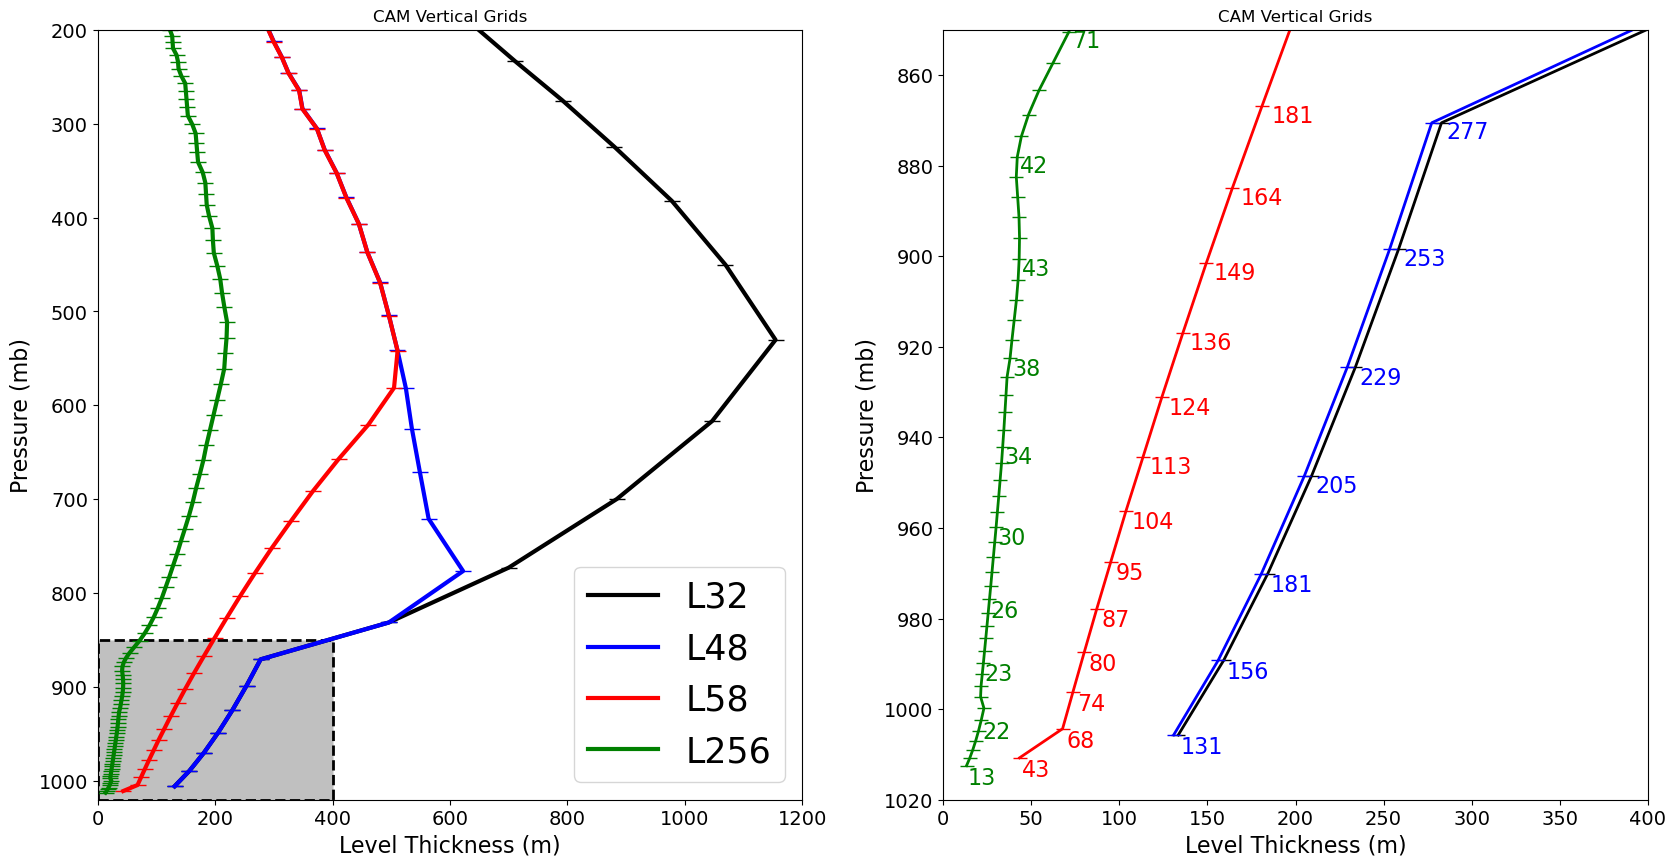

In [9]:
'''
    PLOT SCAM MODEL LEVELS
'''

fig_name = 'cam7_vlev_new256'

colors = ['k','b','r','g']

dir_nc = '/glade/work/rneale/scam_cases/ncdata/'

#dcases = {'L32':'CESM2.F2000climo.64x128.cam.i.0003-06-01-00000.nc',
#          'L48':'FWsc_T42_48L_GRID_48_taperstart10km_lowtop_Top_42km.nc',
#          'L58':'FWsc_T42_58L_GRID_48_taperstart10km_lowtop_BL10_v3_beta1p75_Top_43km.nc',
#          'L256':'CESM2.F2000climo.IOP_SITES_L256.cam.i.0003-06-01-00000.nc',}

#dcases = {'L32':'FWsc_T42_L32_taperstart10km_lowtop_Top_42km.nc',
#          'L48':'FWsc_T42_L48_taperstart10km_lowtop_Top_42km.nc',
#          'L58':'FWsc_T42_L58_taperstart10km_lowtop_Top_42km.nc',
#          'L256':'FWsc_T42_L256_taperstart10km_lowtop_Top_42km.nc',}

dcases = {'L32':'CESM2.F2000climo.64x128.cam.i.0003-07-01-00000_L32.nc',
          'L48':'CESM2.F2000climo.64x128.cam.i.0003-07-01-00000_L48.nc',
          'L58':'CESM2.F2000climo.64x128.cam.i.0003-07-01-00000_L58.nc',
          'L256':'CESM2.F2000climo.64x128.cam.i.0003-07-01-00000_L256.nc',}



# Is it this one for L32 though?
#CESM2.F2000climo.IOP_SITES_L032.cam.i.0003-06-01-00000.nc


dir_fig = '/glade/u/home/rneale/python/python-figs/papers/ZM_PBL/'

# Typical W-Pacific Observed profile in ERA5

lon_bounds = [0.,360.] ; lat_bounds = [80.,90.]
lon_bounds = [120.,1800.] ; lat_bounds = [-20.,20.]


f_temp = '/glade/campaign/cgd/amp/amwg/ADF_obs/T_ERA5_monthly_climo_1degree_197901-202112.nc'
d_temp = xr.open_dataset(f_temp,decode_times=False)

print('Grabbing Mean West Pacific Temperature profile from ADF ERA5 climo files')

clim_t_wp = d_temp['T'].sel(
    lat=slice(lat_bounds[0], lat_bounds[1]),
    lon=slice(lon_bounds[0], lon_bounds[1]))
clim_t_wp = clim_t_wp.mean(dim=["lat", "lon"])
clim_t_wp = clim_t_wp.mean(dim="time")

clim_p_wp = d_temp['lev']



# Plotting

fig, ax = mp.subplots(nrows=1,ncols=2,figsize=(20, 10))

cases_key = list(dcases.keys())


# LOOP CASES #

from scipy.ndimage import gaussian_filter1d

for case in dcases:

    print('*************** ',case,' **********************')
    print('')
    
    f_ds = xr.open_dataset(dir_nc+dcases[case],decode_times=False).squeeze()

    ps_standard = 101325.
    
    plev_m = f_ds['hyam']*f_ds['P0'] + f_ds['hybm']*ps_standard # Mid level
    plev_i = f_ds['hyai']*f_ds['P0'] + f_ds['hybi']*ps_standard # interface level

    plev_m = plev_m*0.01 # Switch to mb for below
    plev_i = plev_i*0.01
    
    # Interpolate temperature to from ERA5 to model levels.
    from scipy.interpolate import interp1d
    f_interp_e2c = interp1d(clim_p_wp, clim_t_wp, kind='linear', bounds_error=False, fill_value='extrapolate')
    mclim_t_wp_c = f_interp_e2c(plev_m)
    iclim_t_wp_c = f_interp_e2c(plev_i)

    #  Approximate height (in meters) from pressure (in hPa)

    p0 = 1013.25  # hPa
    Rd = 287.05   # J/(kg·K)
    g = 9.80665   # m/s²

    z_plevm = np.array(-(Rd * mclim_t_wp_c / g) * np.log(plev_m/p0))
    z_plevi = np.array(-(Rd * iclim_t_wp_c / g) * np.log(plev_i/p0))
    
    dz_lev = np.diff(-z_plevi) # Make it positive thicknesses
    print(dz_lev)
    
    # Smooth near-surface layers and enforce 15 m minimum for L256
    if case == 'L256x':
        n_sm    = 10     # number of bottom layers to smooth
        sigma_sm = 2.5
        dz_lev[-n_sm:] = gaussian_filter1d(dz_lev[-n_sm:], sigma=sigma_sm)
        dz_lev = np.clip(dz_lev, 25.0, None)

    
    print(str(dz_lev[-1]))
    ikey = cases_key.index(case)  
    col = colors[ikey]

    
    ax[0].plot(dz_lev,plev_m,label = case, color=col, lw=3, marker='_',ms=12)
    
    if case == 'L32': dz_lev = 1.02*dz_lev
        
    ax[1].plot(dz_lev,plev_m,label = case, marker='_',color=col,lw=2,ms=10)

    nplev_m = plev_m.size-1
    print(nplev_m-1)
    
    for ii in range(0,nplev_m+1):
        ptext = True
        if (case == 'L32'): ptext = False
        if (case == 'L256') and (ii % 5 != 0): ptext = False
        if ptext and plev_m[ii] > 850.:
            tdz_lev = 1.03*dz_lev[ii]
            tplev_m = 1.004*plev_m[ii]
            ax[1].text(tdz_lev, tplev_m, f"{dz_lev[ii]:.0f}",color=col,fontsize=16)   


# Add a box and lines 
pbox = patches.Rectangle((0, 1020.), 400, -170, linewidth=2, edgecolor='black',ls='--',facecolor = 'silver')
ax[0].add_patch(pbox)


# Plotting
print('PLOTTING')

ax[0].set_ylabel('Pressure (mb)',fontsize=16) ;ax[1].set_ylabel('Pressure (mb)',fontsize=16) 
ax[0].set_xlim([0,1200.]); ax[1].set_xlim([0,400.])

ax[0].set_xlabel('Level Thickness (m)',fontsize=16) ; ax[1].set_xlabel('Level Thickness (m)',fontsize=16) 
ax[0].set_ylim([200,1020]) ; ax[1].set_ylim([850,1020])

ax[0].invert_yaxis() ; ax[1].invert_yaxis()

ax[0].tick_params(axis='x', labelsize=14) ; ax[1].tick_params(axis='x', labelsize=14)
ax[0].tick_params(axis='y', labelsize=14) ; ax[1].tick_params(axis='y', labelsize=14)
ax[0].set_title("CAM Vertical Grids") ; ax[1].set_title("CAM Vertical Grids")

ax[0].legend(fontsize=25)

fig.savefig(dir_fig+fig_name, dpi=150)
